# Polygon Rasterization

`xrspatial.rasterize` converts vector polygons into a 2D `xr.DataArray` using scanline fill.  It works directly from a GeoDataFrame or a list of `(geometry, value)` pairs, with no GDAL dependency.

**Backends:** NumPy (via numba) and CuPy (one CUDA thread per raster row).

This notebook walks through:
1. Rasterizing a simple GeoDataFrame
2. Controlling resolution and bounds
3. Handling overlapping polygons and holes
4. Using the result with other xarray-spatial functions (slope, zonal stats)

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.geometry import box, Polygon, MultiPolygon

from xrspatial.rasterize import rasterize

## 1. Basic rasterization from a GeoDataFrame

Create a GeoDataFrame with three land-use zones and rasterize the `zone_id` column.

In [ ]:
# Three non-overlapping land-use zones
gdf = gpd.GeoDataFrame({
    'zone_id': [1.0, 2.0, 3.0],
    'label': ['forest', 'urban', 'water'],
}, geometry=[
    box(0, 0, 40, 60),    # forest on the left
    box(40, 0, 80, 60),   # urban in the middle
    box(80, 0, 100, 60),  # water on the right
])

raster = rasterize(gdf, width=200, height=120,
                   bounds=(0, 0, 100, 60), column='zone_id', fill=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vector view
gdf.plot(ax=axes[0], column='zone_id', cmap='Set2', edgecolor='black',
         legend=True, legend_kwds={'label': 'zone_id'})
axes[0].set_title('Vector (GeoDataFrame)')

# Raster view
im = axes[1].imshow(raster.values, cmap='Set2', origin='upper',
                    extent=[0, 100, 0, 60])
axes[1].set_title('Rasterized (200×120)')
plt.colorbar(im, ax=axes[1], label='zone_id')
plt.tight_layout()
plt.show()

## 2. Overlapping polygons

When polygons overlap, the last polygon in the GeoDataFrame wins (last-writer-wins).

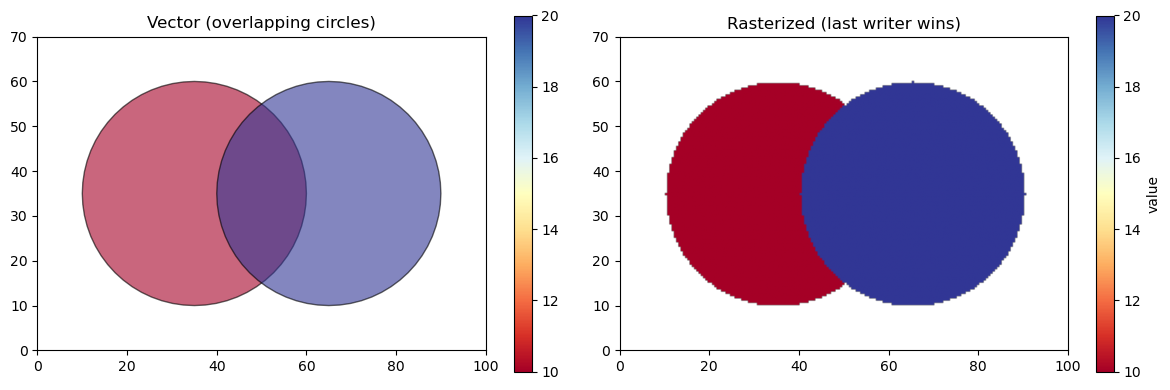

In [6]:
# Two overlapping circles (approximated as polygons)
from shapely.geometry import Point

circle_a = Point(35, 35).buffer(25)
circle_b = Point(65, 35).buffer(25)

gdf_overlap = gpd.GeoDataFrame(
    {'value': [10.0, 20.0]},
    geometry=[circle_a, circle_b],
)

raster_overlap = rasterize(gdf_overlap, width=200, height=140,
                           bounds=(0, 0, 100, 70), column='value')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gdf_overlap.plot(ax=axes[0], column='value', cmap='RdYlBu', alpha=0.6,
                 edgecolor='black', legend=True)
axes[0].set_title('Vector (overlapping circles)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 70)

im = axes[1].imshow(raster_overlap.values, cmap='RdYlBu', origin='upper',
                    extent=[0, 100, 0, 70])
axes[1].set_title('Rasterized (last writer wins)')
plt.colorbar(im, ax=axes[1], label='value')
plt.tight_layout()
plt.show()

## 3. Polygons with holes

Interior rings (holes) are handled correctly -- pixels inside the hole remain unfilled.

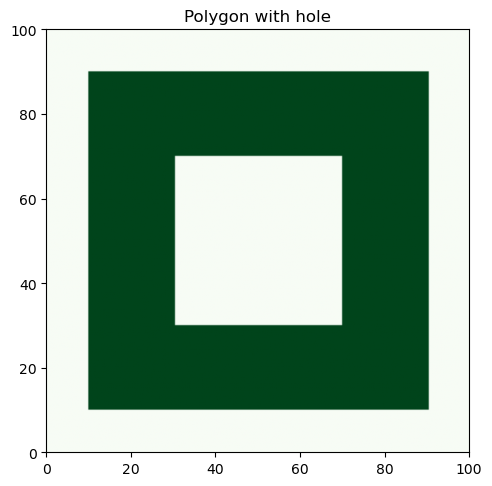

In [7]:
# Polygon with a rectangular hole
exterior = [(10, 10), (90, 10), (90, 90), (10, 90), (10, 10)]
hole = [(30, 30), (30, 70), (70, 70), (70, 30), (30, 30)]
poly_with_hole = Polygon(exterior, [hole])

raster_hole = rasterize([(poly_with_hole, 1.0)],
                        width=200, height=200,
                        bounds=(0, 0, 100, 100), fill=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(raster_hole.values, cmap='Greens', origin='upper',
          extent=[0, 100, 0, 100])
ax.set_title('Polygon with hole')
plt.tight_layout()
plt.show()

## 4. Practical use case: rasterize zones, then compute zonal statistics

Rasterize a set of polygons as a zone raster, generate synthetic elevation, and compute zonal stats.

Zonal statistics (elevation by zone):
   zone        mean         max         min         sum        std  \
0     1  199.071472  454.432190  -32.990555  1990714.75  87.410072   
1     2  349.874268  581.182556  102.518471  3498742.75  87.093697   
2     3  450.369202  677.957336  218.092270  4503692.00  86.928917   
3     4  601.038147  850.860046  370.118195  6010381.50  86.688675   

           var    count    majority  
0  7640.520996  10000.0  374.972137  
1  7585.312012  10000.0  337.710327  
2  7556.636719  10000.0  385.624481  
3  7514.925781  10000.0  527.156006  


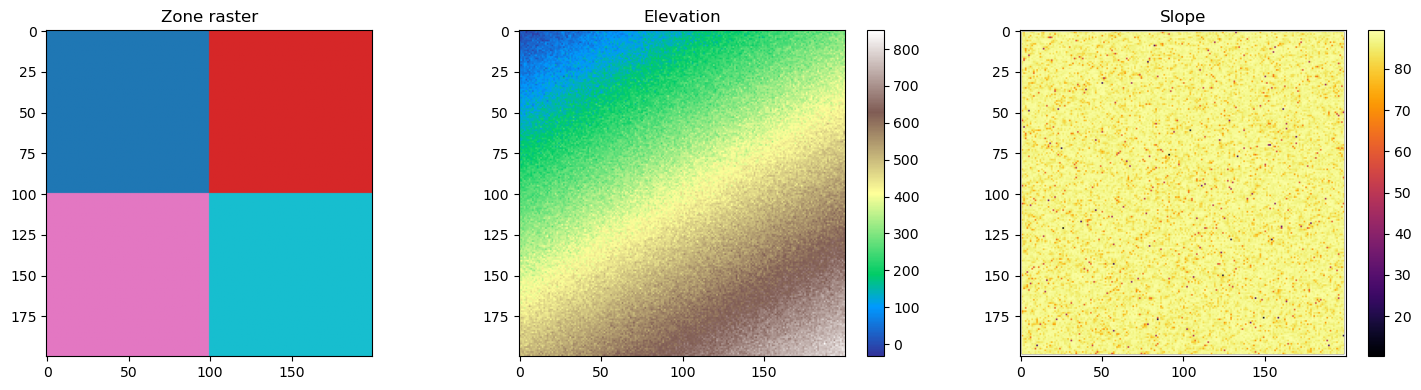

In [8]:
import xarray as xr
from xrspatial import slope
from xrspatial.zonal import stats as zonal_stats

# Create zone polygons
zones_gdf = gpd.GeoDataFrame({
    'zone': [1.0, 2.0, 3.0, 4.0],
    'name': ['NW', 'NE', 'SW', 'SE'],
}, geometry=[
    box(0, 50, 50, 100),
    box(50, 50, 100, 100),
    box(0, 0, 50, 50),
    box(50, 0, 100, 50),
])

# Rasterize zones
zone_raster = rasterize(zones_gdf, width=200, height=200,
                        bounds=(0, 0, 100, 100), column='zone',
                        fill=0, dtype=np.int32)

# Generate synthetic elevation (gradient + noise)
rng = np.random.default_rng(42)
yy, xx = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200),
                     indexing='ij')
elevation_data = (yy * 500 + xx * 300 + rng.normal(0, 20, (200, 200)))
elevation = xr.DataArray(elevation_data.astype(np.float32),
                         dims=['y', 'x'],
                         coords=zone_raster.coords)

# Compute slope
slp = slope(elevation)

# Compute zonal stats
stats_df = zonal_stats(zone_raster, elevation)
print("Zonal statistics (elevation by zone):")
print(stats_df)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(zone_raster.values, cmap='tab10', origin='upper')
axes[0].set_title('Zone raster')
im1 = axes[1].imshow(elevation.values, cmap='terrain', origin='upper')
axes[1].set_title('Elevation')
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(slp.values, cmap='inferno', origin='upper')
axes[2].set_title('Slope')
plt.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()

## 5. Using `all_touched`

By default, only pixels whose center falls inside the polygon are burned.  With `all_touched=True`, any pixel touched by the polygon boundary is included.  This matters most for thin or small features.

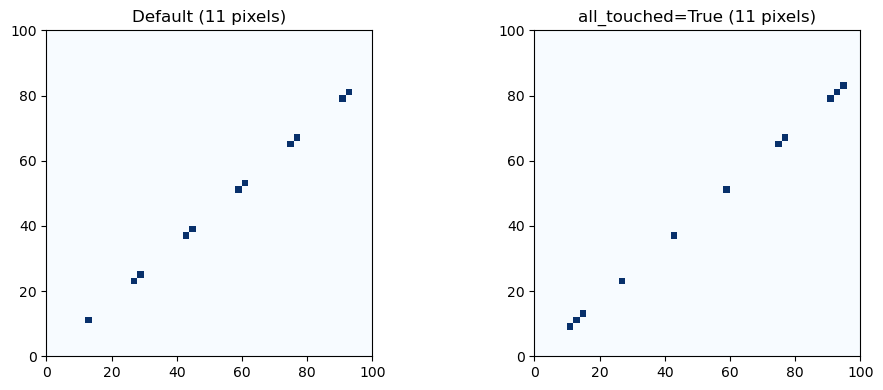

In [9]:
# Thin diagonal strip -- easily missed by center-sampling
thin_strip = Polygon([(10, 10), (90, 80), (92, 82), (12, 12), (10, 10)])

normal = rasterize([(thin_strip, 1.0)], width=50, height=50,
                   bounds=(0, 0, 100, 100), fill=0, all_touched=False)
touched = rasterize([(thin_strip, 1.0)], width=50, height=50,
                    bounds=(0, 0, 100, 100), fill=0, all_touched=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(normal.values, cmap='Blues', origin='upper',
               extent=[0, 100, 0, 100])
axes[0].set_title(f'Default ({int(np.sum(normal.values == 1))} pixels)')
axes[1].imshow(touched.values, cmap='Blues', origin='upper',
               extent=[0, 100, 0, 100])
axes[1].set_title(f'all_touched=True ({int(np.sum(touched.values == 1))} pixels)')
plt.tight_layout()
plt.show()

## 6. List-of-pairs input (no GeoDataFrame needed)

You can skip GeoDataFrame entirely and pass `(geometry, value)` pairs directly.

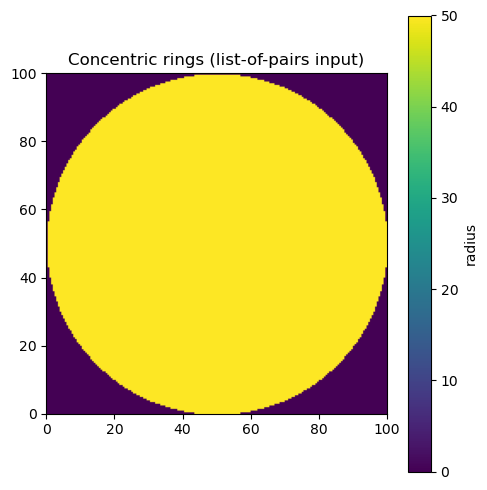

In [10]:
# Concentric rings using list-of-pairs
pairs = []
for radius in [50, 40, 30, 20, 10]:
    circle = Point(50, 50).buffer(radius)
    pairs.append((circle, float(radius)))

rings = rasterize(pairs, width=200, height=200,
                  bounds=(0, 0, 100, 100), fill=0)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(rings.values, cmap='viridis', origin='upper',
               extent=[0, 100, 0, 100])
ax.set_title('Concentric rings (list-of-pairs input)')
plt.colorbar(im, ax=ax, label='radius')
plt.tight_layout()
plt.show()